# **MÓDULO 34 - Regressão: Conceitos Avançados**

Para essa atividade vocês trabalharão com a mesma base que usamos na aula, para previsão do aluguel.

Durante a aula montamos um modelo de regressão polinomial utilizando a variavel Valor Condominio para prever a variavel valor aluguel. Nessa atividade vocês devem escolher outra váriavel dessa base para realizar a previsão do valor do aluguel.


# 1 - Realize a importação das bibliotecas necessárias, carrega a base de dados e separe em X e Y, selecionando uma das váriaveis para X não sendo a usada durante a aula.

- Importações 

In [67]:
# Importações para aquivo

import os

# Importações para os dados

import pandas as pd
import numpy as np

# Importações para Visualização de dados

import plotly.express as px
import matplotlib.pyplot as plt

# Importações para ML

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# Importações para visualização de métricas

from sklearn.metrics import r2_score, mean_squared_error

- Carregando Base de Dados

In [68]:
# Carregando DF

path = '.\\ALUGUEL_MOD12.csv'

if os.path.exists(path): 
    print("O Arquivo foi encontrado!!! ")
else:
    print("O Arquivo não foi encontrado...")

# Atribuindo DF 

df = pd.read_csv(path, sep=';')
df.head(10)

O Arquivo foi encontrado!!! 


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


- Breve análise no df

In [69]:
# Verificando types do DF

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


Obs: Veriquei os tipos e todos estão corretos

In [70]:
# Verificando correlação

df.corr()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
Valor_Aluguel,1.000000,0.695302,0.730591,0.413139,0.603715,0.614397,0.652858
Valor_Condominio,0.695302,1.000000,0.805926,0.497420,0.585795,0.589244,0.690993
Metragem,0.730591,0.805926,1.000000,0.678091,0.687558,0.696281,0.743872
N_Quartos,0.413139,0.497420,0.678091,1.000000,0.553807,0.540887,0.591224
N_banheiros,0.603715,0.585795,0.687558,0.553807,1.000000,0.920149,0.694983
N_Suites,0.614397,0.589244,0.696281,0.540887,0.920149,1.000000,0.712054
N_Vagas,0.652858,0.690993,0.743872,0.591224,0.694983,0.712054,1.000000


Obs: Verifiquei as correlações para decir qual será a melhor variável para a predição, e escolherei a metragem

In [71]:
# Verificando se há algum outlier

df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


Obs: Eu já fiz uma EDA mais detalhada nessa base anteriormente, logo, não farei novamente, e o que eu havia descobrido era que mesmo com valor bem altos em alguns casos eles fazem sentido quando comparados com as outras váriaveis, ou seja, não são erros de digitação ou algo relacionado, podem, na verdade, se tratar de uma mansão/apartamento de luxo. 

- Separando X e y

In [72]:
# Realizando separação de X e y e a variável escolhida foi metragem por sua alta correlação com a variável target.

X = df[['Metragem']]
y = df['Valor_Aluguel']


A variável Metragem foi escolhida por apresentar uma correlação relativamente alta com a variável alvo e, ao mesmo tempo, por possuir uma relação intuitiva com o valor do aluguel, o que favorece tanto a modelagem quanto a interpretação do resultado.

# 2 - Faça o procecssamento dos dados utilizando o Polynomial Feature, com degree = 2.

- Polynomial feature com degree 2

In [73]:
# Criando variável

poly_f2 = PolynomialFeatures(degree=2)

- Aplicando em X

In [74]:
# Aplicando Polynomial Features em X

X_poly_2 = poly_f2.fit_transform(X)

# 3 - Separe os dados em treino e teste e realize o treinamento do modelo.

- Separando modelo em treino e teste

In [75]:
# Separando modelo

X_train, X_test, y_train, y_test = train_test_split(X_poly_2, y, test_size=0.2, random_state=48)

# Verificando se está certo

print(" O tamanho de X_train é ", X_train.shape)
print("O tamanho de X_test é ", X_test.shape)
print("O tamanho de y_train é ", y_train.shape)
print("O tamanho de y_test é ", y_test.shape)

 O tamanho de X_train é  (5762, 3)
O tamanho de X_test é  (1441, 3)
O tamanho de y_train é  (5762,)
O tamanho de y_test é  (1441,)


- Treinando Modelo

In [76]:
# Criando Modelo

model_poly2 = LinearRegression()

# Treinando modelo

model_poly2.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 4 - Faça as previsões para a base de teste e avalie os resultados obtidos, não se esqueça de plotar o gráfico da regressão.

- Realizando previsões e verificando resultado

In [77]:
# Previsões

y_pred = model_poly2.predict(X_test)

# Verificando resultados

r2 = r2_score(y_test, y_pred)
print(f"O R² da Regressão Polinomial de 2 grau é {r2:.4f}")
mse2 = mean_squared_error(y_test, y_pred)
print(f"O MSE da Regressão Polinomial de 2 grau é {mse2:.2f}")
rmse = np.sqrt(mse2)
print(f"O RMSE da Regressão Polinomial de 2 grau é {rmse:.2f}")

O R² da Regressão Polinomial de 2 grau é 0.5485
O MSE da Regressão Polinomial de 2 grau é 4160957.98
O RMSE da Regressão Polinomial de 2 grau é 2039.84


Pelos resultados das métricas, podemos ver que o modelo não está ruim, mas ainda precisa de refinamento e da utilização de outras variáveis para se tornar realmente útil. Todavia, apenas com uma variável, o modelo mostrou conseguir explicar, de acordo com o R², quase 55% da variação do valor do aluguel, ou seja, ele já possui alguma capacidade preditiva, principalmente considerando as condições do exercício. Porém, ainda está longe de ser considerado um bom modelo. Isso fica ainda mais evidente quando observamos o RMSE, que foi de 2039.

- Plotando o Gráfico

C:\Users\MIGUEL\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


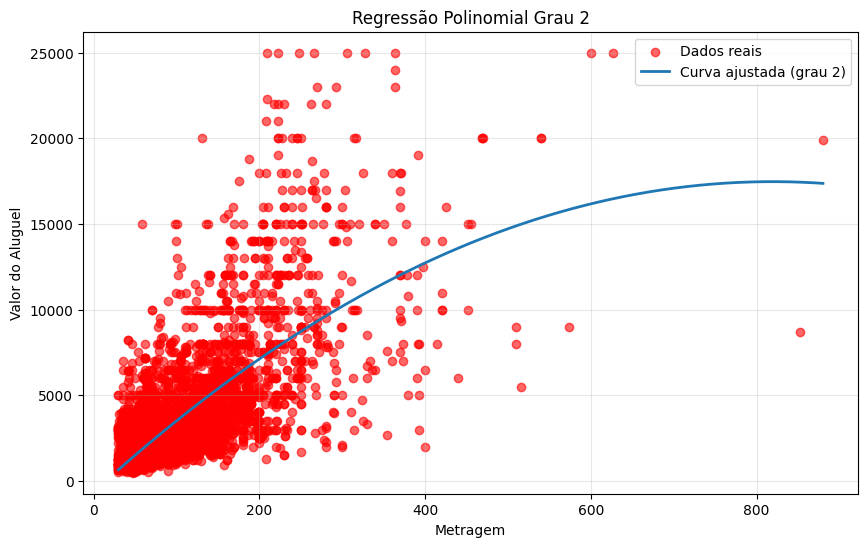

In [85]:
# Criando uma sequência contínua e ordenada de valores para Metragem
x_range = np.linspace(X.min().values[0], X.max().values[0], 500).reshape(-1, 1)

# Transformando para grau 2
x_range_poly_2 = poly_f2.transform(x_range)

# Previsões da curva
y_range_pred_2 = model_poly2.predict(x_range_poly_2)

# Gráfico
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', alpha=0.6, label='Dados reais')
plt.plot(x_range, y_range_pred_2, linewidth=2, label='Curva ajustada (grau 2)')

plt.title('Regressão Polinomial Grau 2')
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Obs.: O modelo teve um resultado aceitável, levando em consideração que há bastante variabilidade nos dados e que é difícil realizar uma predição muito precisa utilizando apenas uma variável. Ainda assim, o modelo não foi ruim; com a utilização de outras variáveis e, possivelmente, com um pré-processamento melhor, ele pode apresentar resultados bem superiores, o que demonstra potencial.

# 5 - Refaça os passos anteriores, rodando um novo modelo, porém testando agora na fase de processamento o degree = 4. Avalie se o resultado desse novo modelo está superior ao anterior.

- Polinomial features grau 4

In [79]:
# Criando a polynomial de grau 4

poly_f4 = PolynomialFeatures(degree=4)

- Aplicando em X

In [80]:
# Aplicando a polynomial de grau 4 em X

X_poly_4 = poly_f4.fit_transform(X)

- Separando em treino e em teste

In [81]:
# Separando em treino e teste com o tamanho de teste sendo 20% e um random state de 48.

X_train, X_test, y_train, y_test = train_test_split(X_poly_4, y, test_size=0.2, random_state=48)

# Verificando se está certo

print(" O tamanho de X_train é ", X_train.shape)
print("O tamanho de X_test é ", X_test.shape)
print("O tamanho de y_train é ", y_train.shape)
print("O tamanho de y_test é ", y_test.shape)

 O tamanho de X_train é  (5762, 5)
O tamanho de X_test é  (1441, 5)
O tamanho de y_train é  (5762,)
O tamanho de y_test é  (1441,)


- Criando e treinando o modelo

In [82]:
# Criando o modelo de regrassão polinomial

model_poly4 = LinearRegression()

# Treinamento do modelo

model_poly4.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- Realizando previsões e verificando resultados

In [83]:
# Realizando previsões

y_pred = model_poly4.predict(X_test)

# Verificando resultados

r2 = r2_score(y_test, y_pred)
print(f"O R² da Regressão Polinomial de 4 grau é {r2:.4f}")
mse = mean_squared_error(y_test, y_pred)
print(f"O MSE da Regressão Polinomial de 4 grau é {mse:.2f}")
rmse = np.sqrt(mse)
print(f"O RMSE da Regressão Polinomial de 4 grau é {rmse:.2f}")

O R² da Regressão Polinomial de 4 grau é 0.5431
O MSE da Regressão Polinomial de 4 grau é 4210599.84
O RMSE da Regressão Polinomial de 4 grau é 2051.97


- Plotando Gráfico

C:\Users\MIGUEL\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


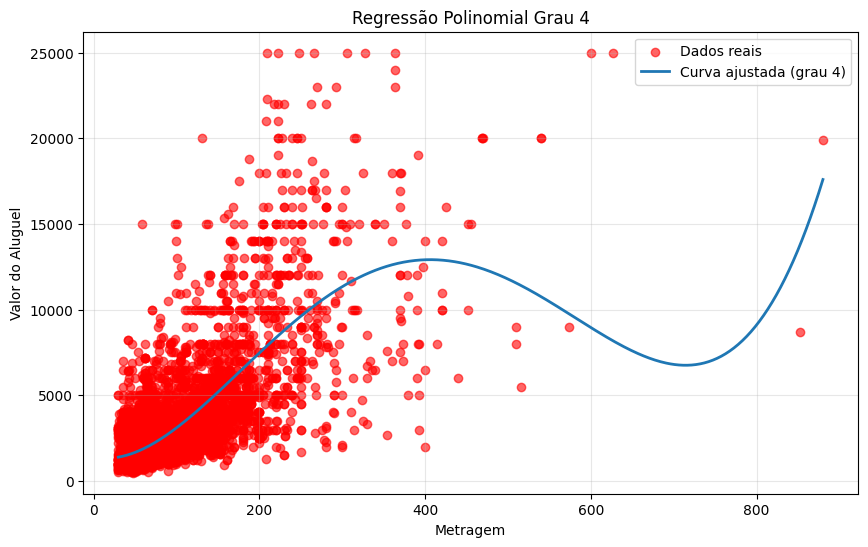

In [86]:
# Criando a mesma faixa contínua
x_range = np.linspace(X.min().values[0], X.max().values[0], 500).reshape(-1, 1)

# Transformando para grau 4
x_range_poly_4 = poly_f4.transform(x_range)

# Previsões da curva
y_range_pred_4 = model_poly4.predict(x_range_poly_4)

# Gráfico
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', alpha=0.6, label='Dados reais')
plt.plot(x_range, y_range_pred_4, linewidth=2, label='Curva ajustada (grau 4)')

plt.title('Regressão Polinomial Grau 4')
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Comparação entre Grau 2 e Grau 4

No final das contas, por mais impressionante que possa parecer, o modelo de grau 2 ficou um pouco melhor que o modelo de grau 4. Isso mostra que aumentar o grau do modelo não é, necessariamente, uma garantia de melhoria. No modelo de grau 4, o R² foi levemente inferior e o RMSE apresentou valor um pouco maior, indicando que elevar o grau não apenas deixou o modelo mais complexo e mais propenso a overfitting, como também piorou métricas que já não eram das melhores. Esse resultado diz que modelos mais complexos não necessariamente generalizam melhor, e que o aumento do grau polinomial deve ser acompanhado por verificação cuidadosa, e não apenas pela expectativa de melhora.

# 6 - Explique com suas palavras o conceito e a diferença entre Elastic Net, Ridge e Lasso.
Minimo: 4 linhas.

Elastic Net, Ridge e Lasso

Primeiro, para explicar suas diferenças e facilitar o entendimento, é importante dizer o que são e para que servem. Todos são técnicas de regularização de modelos, ou seja, têm como objetivo melhorar o desempenho do modelo, podendo inclusive melhorar métricas, mas principalmente reduzir o risco de overfitting. Ainda assim, cada uma tende a ser mais útil em cenários diferentes.

Lasso aplica regularização L1. Em termos práticos, ele pode reduzir bastante a influência de variáveis pouco úteis e, em alguns casos, zerar seus coeficientes, funcionando também como uma forma de seleção de variáveis.

Ridge aplica regularização L2. Em vez de zerar coeficientes, ele tende a reduzi-los, sendo especialmente útil quando há multicolinearidade, isto é, quando variáveis explicativas possuem correlação muito alta entre si. Isso ajuda a estabilizar o modelo e reduzir a sensibilidade a esse tipo de problema.

Elastic Net combina L1 e L2, reunindo características do Lasso e do Ridge. Assim, ele pode ao mesmo tempo reduzir coeficientes, lidar melhor com multicolinearidade e ainda eliminar algumas variáveis menos relevantes, dependendo do cenário.

A principal diferença entre eles está justamente no tipo de penalização aplicada e no contexto em que cada um tende a funcionar melhor. Se você estiver trabalhando com uma base mais ruidosa e com variáveis pouco relevantes, o Lasso pode ser mais interessante. Se o problema principal estiver na alta correlação entre variáveis explicativas, o Ridge costuma ser uma opção forte. Já quando a base apresenta as duas situações, o Elastic Net pode ser a alternativa mais equilibrada. De todo modo, o ideal é sempre testar e comparar para descobrir qual técnica faz mais sentido para aquela base específica.